In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

## Нафикова Лиана

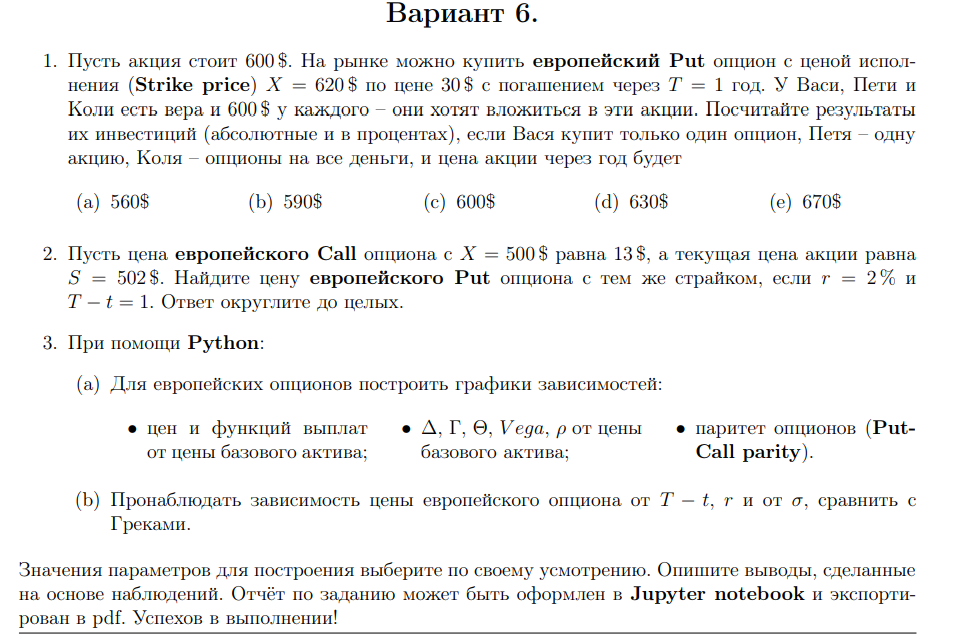

### Задание 1

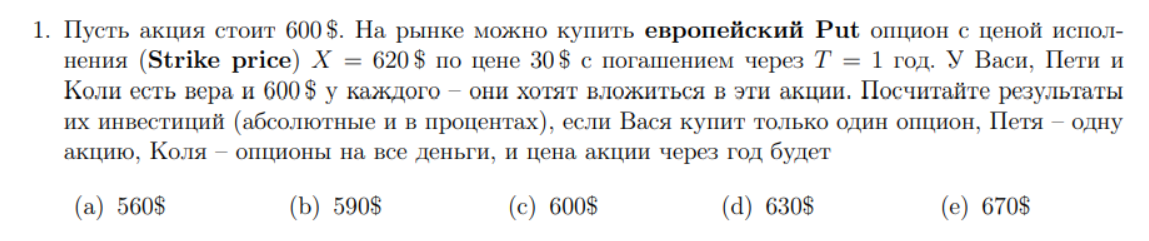

**Рассчитаем для Васи:**

Вася покупает 1 опцион за 30 \$

1. Если цена акции через год 560\$, то 
Вася, продавая опцион за 620\$, получает прибыль от опционна 60\$. Чистая прибыль 30\$.
В процентах (прибыль от первоначальной инвестиции) $30/30*100\% = 100\%$

2. Если цена акции через год 590\$, то 
Вася, продавая опцион за 620\$, получает прибыль от опционна 30\$. Чистая прибыль 0\$.
В процентах (прибыль от первоначальной инвестиции) $0/30*100\% = 0\%$

3. Если цена акции через год 600\$, то 
Вася, продавая опцион за 620\$, получает убыль от опционна 20\$. Чистая прибыль в убытке $-10\$$.
В процентах (прибыль от первоначальной инвестиции) $-10/30*100\% = -33.33\%$

4. Если цена акции через год 620\$, то опцион бесполезен. Убыток в 30\$ = 100% 

5. Если цена акции через год 670\$, то опцион бесполезен. Убыток в 30\$ = 100% 

**Рассчитаем для Пети:**

Петя покупает одну акцию за 600 \$

1. Если цена акции через год 560\$, то 
Петя в убытке на 40\$. 
В процентах (прибыль от первоначальной инвестиции) $-40/600*100\% = -6.7\%$

2. Если цена акции через год 590\$, то 
Петя в убытке на 10\$. 
В процентах (прибыль от первоначальной инвестиции) $-10/600*100\% = -1.7\%$

3. Если цена акции через год 600\$, то 
Петя в убытке/прибыли на 0. 0\%

4. Если цена акции через год 620\$, то Петя получает прибыль 20\$. Прибыль в прочентах $20/600*100\% = 3.4\%$
 
5. Если цена акции через год 670\$, то Петя получает прибыль 70\$. Прибыль в прочентах $70/600*100\% = 11.7\%$

**Рассчитаем для Коли:**

Коля покупает 20 опционов по 30\$

1. Если цена акции через год 560\$, то 
Коля, продавая опцион за 620\$, получает прибыль от опционна $60\$ * 20 = 1200\$ $. Чистая прибыль $30\$ * 20 = 600\$$.
В процентах (прибыль от первоначальной инвестиции) $600/600*100\% = 100\%$

2. Если цена акции через год 590\$, то 
Коля, продавая опцион за 620\$, получает прибыль от опционна $30\$ * 20 = 600\$ $. Чистая прибыль $0\$ * 20 = 0\$$.
В процентах (прибыль от первоначальной инвестиции) $0/600*100\% = 0\%$

3. Если цена акции через год 600\$, то 
Вася, продавая опцион за 620\$, получает убыль $-200\$$.
В процентах (прибыль от первоначальной инвестиции) $-200/600*100\% = -33.33\%$

4. Если цена акции через год 620\$, то опцион бесполезен. Убыток в 600\$ = 100% 

5. Если цена акции через год 670\$, то опцион бесполезен. Убыток в 600\$ = 100%

### Задание 2

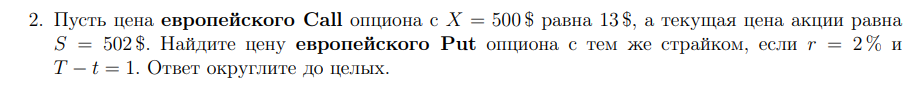

$$X = 500 \$; S = 502 \$; C = 13 \$; r = 2\%; T-t =1$$
$$P - ?$$

Решение: 

Воспользуемся формулой

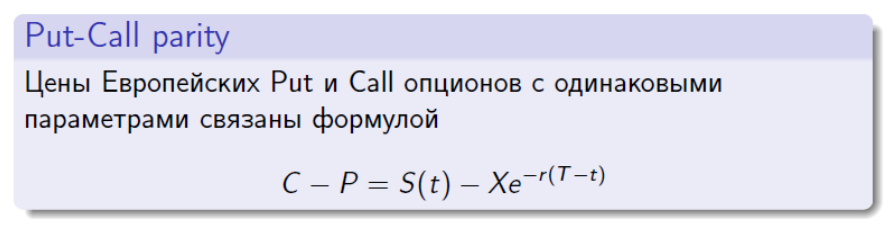

$$13 - P = 502 - 500*e^{-0.02}$$
$$P = 13 - 502 + 500*e^{-0.02} $$
Приблизительная цена $ P = 1\$ $

### Задание 3

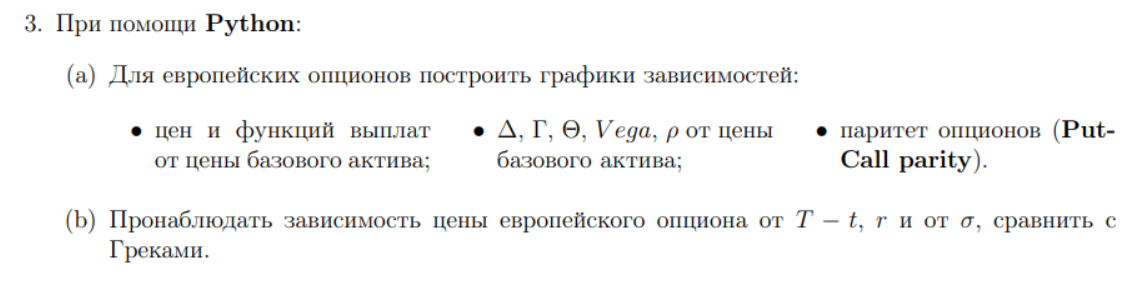

In [52]:
S0 = 100       
K = 100       # Цена страйк
T = 1         
r = 0.05      
sigma = 0.2   # Волатильность

In [53]:
dt = 1/252    # Шаг времени (1 день, если 252 торговых дня в году)
n_steps = int(T / dt)  

In [54]:
def geometric_brownian_motion(S0, r, sigma, dt, n_steps):
    """
    Моделирует геометрическое броуновское движение для цены актива.

    Args:
        S0: Начальная цена актива.
        r:  Безрисковая процентная ставка.
        sigma: Волатильность.
        dt: Шаг времени.
        n_steps: Количество шагов времени.

    Returns:
        Массив, содержащий пути цены актива.
    """
    dW = np.random.normal(0, np.sqrt(dt), size=(n_steps, 1)) 

    S = np.zeros((n_steps + 1, 1))
    S[0] = S0  

    for t in range(n_steps):
        S[t+1] = S[t] * np.exp((r - 0.5 * sigma**2) * dt + sigma * dW[t])

    return S

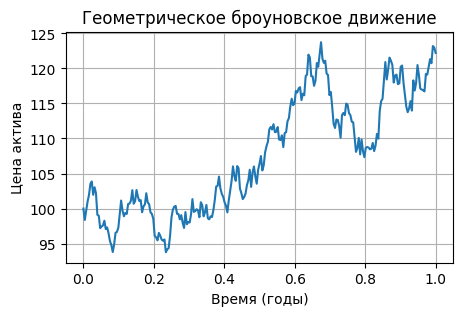

In [55]:
S = geometric_brownian_motion(S0, r, sigma, dt, n_steps)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, T + dt, dt), S[:, 0])

plt.xlabel("Время (годы)")
plt.ylabel("Цена актива")
plt.title("Геометрическое броуновское движение")
plt.grid(True)
plt.show()

##### Задание a

In [56]:
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def black_scholes_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

In [57]:
S_range = np.arange(50, 150, 1)
call_prices = [black_scholes_call(s, K, T, r, sigma) for s in S_range]
put_prices = [black_scholes_put(s, K, T, r, sigma) for s in S_range]
call_payoffs = [max(s - K, 0) for s in S_range]
put_payoffs = [max(K - s, 0) for s in S_range]

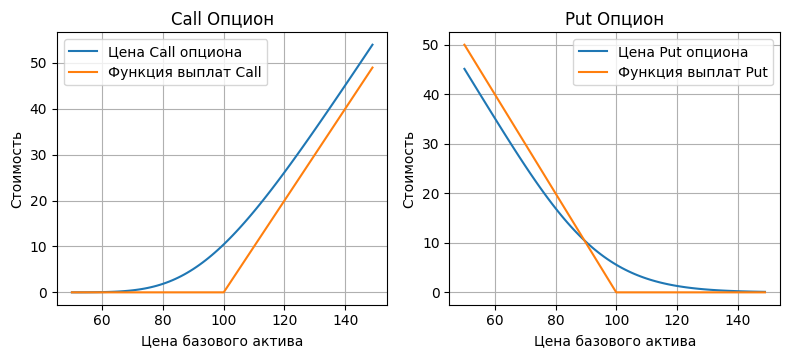

In [58]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4)) 

axs[0].plot(S_range, call_prices, label='Цена Call опциона')
axs[0].plot(S_range, call_payoffs, label='Функция выплат Call')
axs[0].set_xlabel('Цена базового актива')
axs[0].set_ylabel('Стоимость')
axs[0].set_title('Call Опцион')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(S_range, put_prices, label='Цена Put опциона')
axs[1].plot(S_range, put_payoffs, label='Функция выплат Put')
axs[1].set_xlabel('Цена базового актива')
axs[1].set_ylabel('Стоимость')
axs[1].set_title('Put Опцион')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
plt.show()

In [59]:
def delta_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def delta_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1) - 1

def gamma(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def theta_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)

def theta_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)

def vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def rho_call(S, K, T, r, sigma):
    d2 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T)) - sigma * np.sqrt(T)
    return K * T * np.exp(-r * T) * norm.cdf(d2)

def rho_put(S, K, T, r, sigma):
    d2 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T)) - sigma * np.sqrt(T)
    return -K * T * np.exp(-r * T) * norm.cdf(-d2)

In [60]:
call_deltas = [delta_call(s, K, T, r, sigma) for s in S_range]
put_deltas = [delta_put(s, K, T, r, sigma) for s in S_range]
gammas = [gamma(s, K, T, r, sigma) for s in S_range]
call_thetas = [theta_call(s, K, T, r, sigma) for s in S_range]
put_thetas = [theta_put(s, K, T, r, sigma) for s in S_range]
vegas = [vega(s, K, T, r, sigma) for s in S_range]
call_rhos = [rho_call(s, K, T, r, sigma) for s in S_range]
put_rhos = [rho_put(s, K, T, r, sigma) for s in S_range]

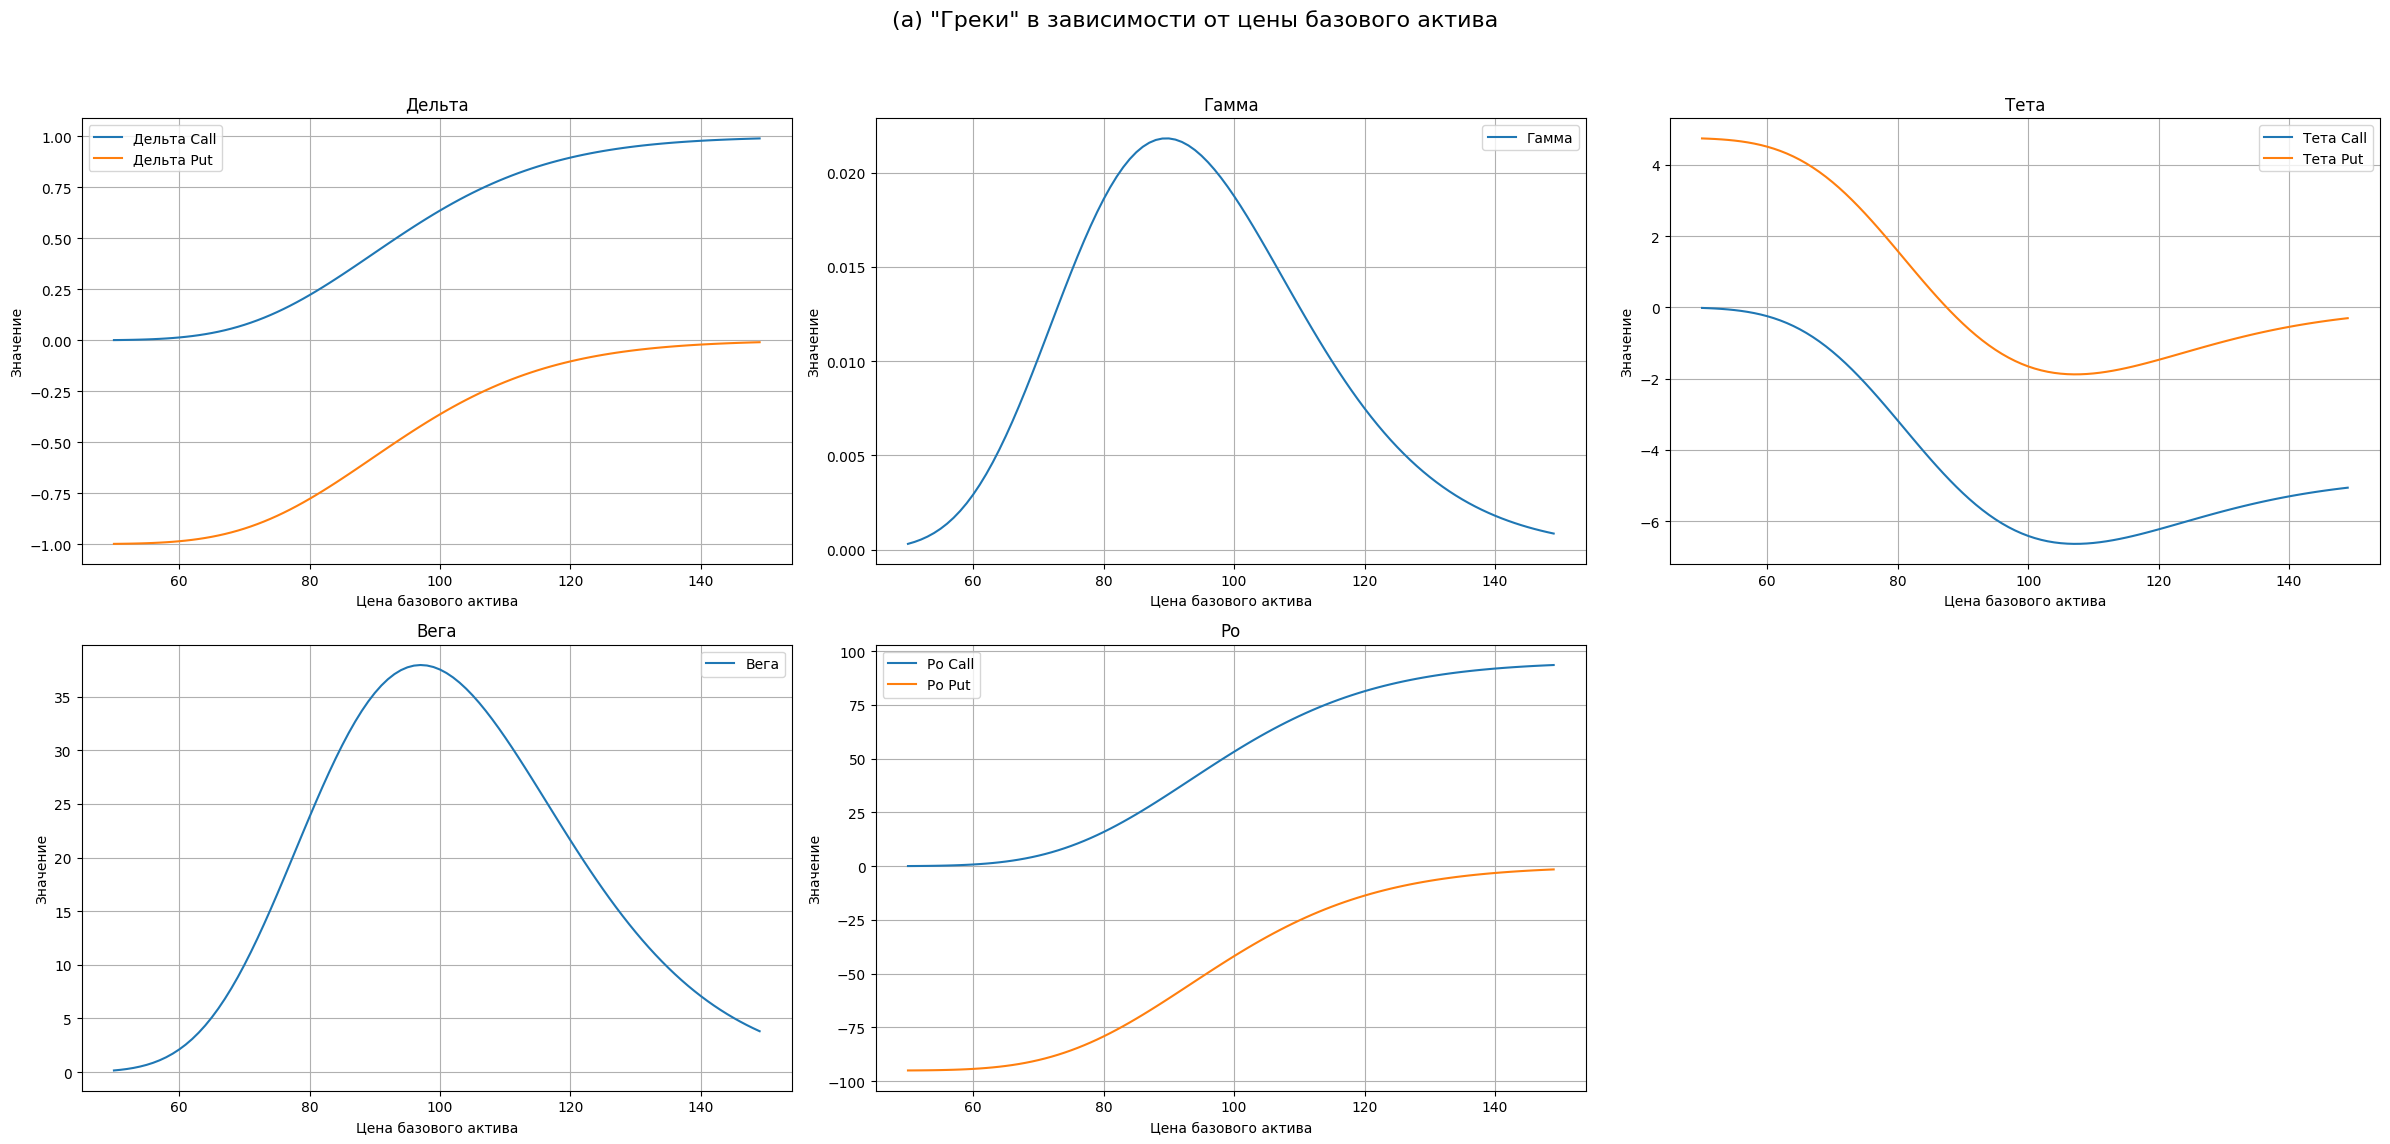

In [61]:
fig, axs = plt.subplots(2, 3, figsize=(24, 12))
axs = axs.flatten()  

# Delta
axs[0].plot(S_range, call_deltas, label='Дельта Call')
axs[0].plot(S_range, put_deltas, label='Дельта Put')
axs[0].set_xlabel('Цена базового актива')
axs[0].set_ylabel('Значение')
axs[0].set_title('Дельта')
axs[0].legend()
axs[0].grid(True)

# Gamma
axs[1].plot(S_range, gammas, label='Гамма')
axs[1].set_xlabel('Цена базового актива')
axs[1].set_ylabel('Значение')
axs[1].set_title('Гамма')
axs[1].legend()
axs[1].grid(True)

# Theta
axs[2].plot(S_range, call_thetas, label='Тета Call')
axs[2].plot(S_range, put_thetas, label='Тета Put')
axs[2].set_xlabel('Цена базового актива')
axs[2].set_ylabel('Значение')
axs[2].set_title('Тета')
axs[2].legend()
axs[2].grid(True)

# Vega
axs[3].plot(S_range, vegas, label='Вега')
axs[3].set_xlabel('Цена базового актива')
axs[3].set_ylabel('Значение')
axs[3].set_title('Вега')
axs[3].legend()
axs[3].grid(True)

# Rho
axs[4].plot(S_range, call_rhos, label='Ро Call')
axs[4].plot(S_range, put_rhos, label='Ро Put')
axs[4].set_xlabel('Цена базового актива')
axs[4].set_ylabel('Значение')
axs[4].set_title('Ро')
axs[4].legend()
axs[4].grid(True)

fig.delaxes(axs[5])

fig.suptitle('(а) "Греки" в зависимости от цены базового актива', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
plt.show()

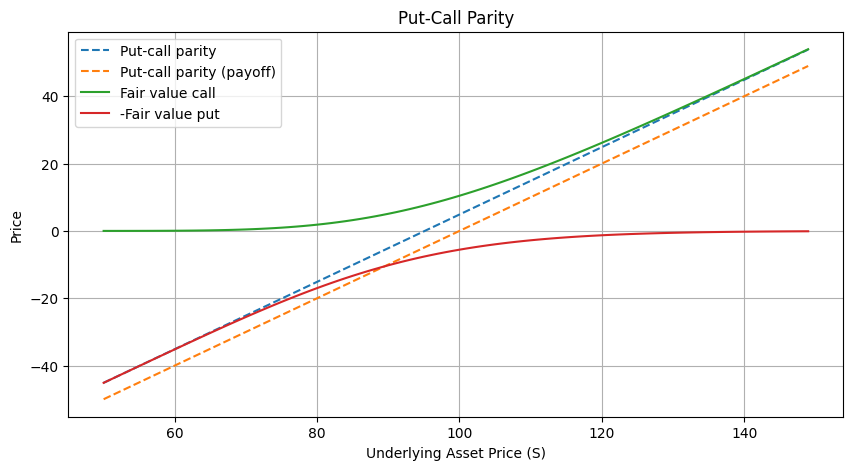

In [71]:
call_prices = [black_scholes_call(s, K, T, r, sigma) for s in S_range]
negative_put_prices = [-black_scholes_put(s, K, T, r, sigma) for s in S_range]
parity = [s - K * np.exp(-r * T) for s in S_range]
parity_payoff = S_range - K

plt.figure(figsize=(10, 5))

plt.plot(S_range, parity, label='Put-call parity', linestyle='--')
plt.plot(S_range, parity_payoff, label='Put-call parity (payoff)', linestyle='--')
plt.plot(S_range, call_prices, label='Fair value call')
plt.plot(S_range, negative_put_prices, label='-Fair value put')  # Fixed label to negative

plt.xlabel('Underlying Asset Price (S)')
plt.ylabel('Price')
plt.title('Put-Call Parity')
plt.legend()
plt.grid(True)
plt.show()

##### Задание b

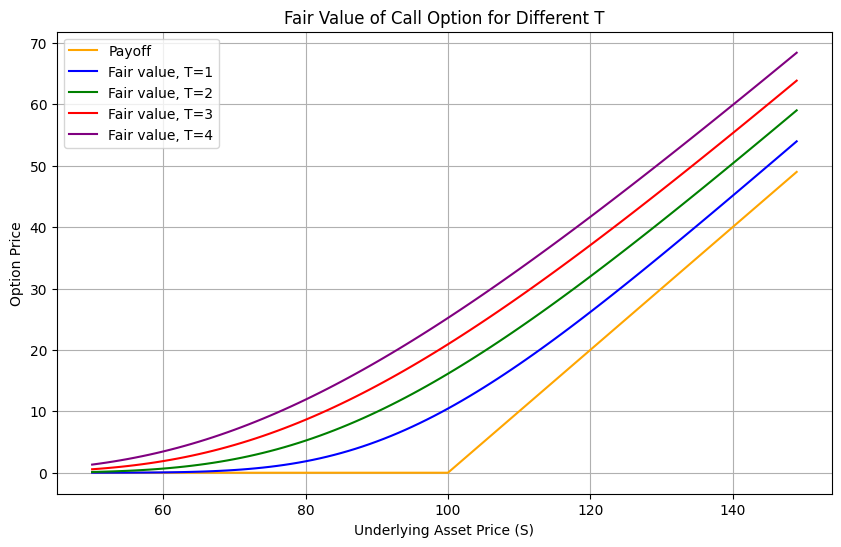

In [73]:
T_values = [1, 2, 3, 4] 
def payoff(S, K):
  return np.maximum(S - K, 0)

plt.figure(figsize=(10, 6))

plt.plot(S_range, payoff(S_range, K), label='Payoff', color='orange')

colors = ['blue', 'green', 'red', 'purple'] 
for i, T in enumerate(T_values):
    call_prices = [black_scholes_call(s, K, T, r, sigma) for s in S_range]
    plt.plot(S_range, call_prices, label=f'Fair value, T={T}', color=colors[i])

plt.xlabel('Underlying Asset Price (S)')
plt.ylabel('Option Price')
plt.title('Fair Value of Call Option for Different T')
plt.legend()
plt.grid(True)
plt.show()

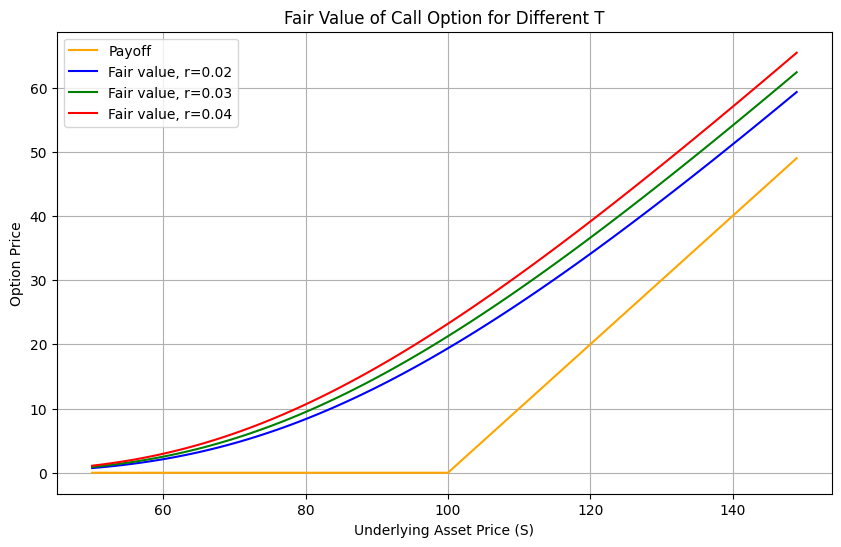

In [ ]:
r_values = [0.02, 0.03, 0.04] 
def payoff(S, K):
  return np.maximum(S - K, 0)

plt.figure(figsize=(10, 6))

plt.plot(S_range, payoff(S_range, K), label='Payoff', color='orange')

colors = ['blue', 'green', 'red', 'purple'] 
for i, r in enumerate(r_values):
    call_prices = [black_scholes_call(s, K, T, r, sigma) for s in S_range]
    plt.plot(S_range, call_prices, label=f'Fair value, r={r}', color=colors[i])

plt.xlabel('Underlying Asset Price (S)')
plt.ylabel('Option Price')
plt.title('Fair Value of Call Option for Different r')
plt.legend()
plt.grid(True)
plt.show()